# RETAIL STORE CUSTOMER CLUSTERING


## LOADING DATASET


> In this step the  online retail dataset is loaded in to the environment for further analysis.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [3]:
import pandas as pd
df=pd.read_excel("Online Retail.xlsx")

### Understanding Dataset

> In this step, we explore the structure and characteristics of the dataset.

In [4]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## DATA CLEANING

> In this step, we clean the datset by handling missing values and removing invalid records.

### Checking missing values

In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


### Dropping the null value rows of CustomerID

> We are dropping the entire columns or rows of CustomerID because
>> When there is no customer ID there is no customer, when there is no customer the row is useless for clustering.

In [9]:
df=df.dropna(subset=['CustomerID'])
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [10]:
df.shape

(406829, 8)

### Retaining Fields Where Quantity & UnitPrice Greater Than Zero


In [11]:
df=df[df['Quantity']>0]
df=df[df['UnitPrice']>0]
df.shape

(397884, 8)

> Rows with negative quantity values represent returned or cancelled transactions. Since the objective of this project is to analyze customer purchasing behavior, only valid purchase transactions are retained by removing negative quantities.

> Rows with zero or negative unit prices may indicate free items or data entry errors.
These records can distort the monetary analysis, so they are removed to ensure accurate results.

## Data Formatting



### Converting InvoiceDate to DateTime format

In [12]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

> The InvoiceDate column is converted into date time format to enable time-based analysis such as recency calculations and trend analysis.

### Converting CustomerID to Integer Format





In [13]:
df['CustomerID']=df['CustomerID'].astype(int)

## Saving the cleaned file

In [14]:
df.to_excel("cleaned_online_retail.xlsx", index=False)

# RFM Feature Engineering
> The Term RFM refers to Recency, Frequency, Monetary.


## Creating Total Amount Feature (Monetary Base)




In [15]:
df=pd.read_excel("cleaned_online_retail.xlsx")
df["Total amount"]= df["Quantity"]* df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


> This represents the total spending for each transaction and is used to calculate the monetary value of each customer.

## Recency Calculation

### Create SnapShot Date

In [16]:
snapshot_date= df['InvoiceDate'].max()+pd.Timedelta(days=1)

### Calculating Recency

In [17]:
recency_df=df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x:(snapshot_date - x.max()).days
})

### Rename Column

In [18]:
recency_df.rename(columns={"InvoiceDate": "Recency"}, inplace=True)

In [19]:
recency_df.head()

,Recency
CustomerID,
12346,326
12347,2
12348,75
12349,19
12350,310


> A snapshot date is defined as one day after the latest transaction date, and recency is calculated as the difference between the snapshot date and the most recent purchase date for each customer.

## Frequency Calculation

In [20]:
frequency_df=df.groupby("CustomerID").agg({
    "InvoiceNo": "nunique"
})

### Renaming Columns

In [21]:
frequency_df.rename(columns={"InvoiceNo":"Frequency"}, inplace=True)
frequency_df.head()

,Frequency
CustomerID,
12346,1
12347,7
12348,4
12349,1
12350,1


> Frequency represents the number of transactions made by each customer.
It is calculated by counting the number of unique invoices associated with each customer.

## Monetary Measurement

In [22]:
monetary_df=df.groupby("CustomerID").agg({
    "Total amount": "sum"
})

### Renaming Columns

In [23]:
monetary_df.rename(columns={"Total amount": "Monetary"}, inplace=True)
monetary_df.head()

,Monetary
CustomerID,
12346,77183.60
12347,4310.00
12348,1797.24
12349,1757.55
12350,334.40


> Monetary value represents the total amount spent by each customer.
It is calculated by summing the total transaction amounts for each customer.

# Creating RFM Table

In [24]:
rfm=recency_df.merge(frequency_df, on="CustomerID")
rfm=rfm.merge(monetary_df, on="CustomerID")

In [25]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


> The Recency, Frequency, and Monetary features are combined into a single RFM table.
This table represents customer behavior and is used as input for clustering.

# Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm)
rfm_scaled.shape


(4338, 3)

>The RFM features are scaled using StandardScaler to bring all variables to a similar scale.
This is important because K-Means clustering is distance-based, and features with larger values can dominate the clustering process if not scaled.

# K-Means Clustering

In [28]:
from sklearn.cluster import KMeans
Kmeans=KMeans(n_clusters=4, random_state=42)
rfm["Cluster"]=Kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,3
12347,2,7,4310.00,0
12348,75,4,1797.24,0
12349,19,1,1757.55,0
12350,310,1,334.40,1


> K-Means clustering is applied to segment customers into groups based on their RFM values.
The number of clusters is initially set to 4, and each customer is assigned to a cluster based on similarity.

## Analyze Clusters

In [29]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


> The average RFM values for each cluster are analyzed to understand customer behavior.
Based on these values, meaningful customer segments such as high-value customers, regular customers, and inactive customers can be identified.

## Assigning Customer Segments

In [30]:
cluster_mapping={
    2: "High Value Customers",
    3: "Loyal customers",
    0: "Regular Customers",
    1: "Inactive Customers"
}
rfm['Segment']=rfm["Cluster"].map(cluster_mapping)
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346,326,1,77183.60,3,Loyal customers
12347,2,7,4310.00,0,Regular Customers
12348,75,4,1797.24,0,Regular Customers
12349,19,1,1757.55,0,Regular Customers
12350,310,1,334.40,1,Inactive Customers


> This improves interpretability and helps in understanding customer behavior more effectively.

# PCA (Principal Component Analysis)

### It is a technique to:
> Reduce number of features while keeping maximum information.

> It compresses 3D data into 2D.

In [31]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
rfm_pca=pca.fit_transform(rfm_scaled)
rfm_pca.shape

(4338, 2)

### Converting to Data Frame

In [32]:
rfm_pca_df=pd.DataFrame(rfm_pca, columns=["PC1", "PC2"])
rfm_pca_df.head()

,PC1,PC2
0,4.106623,5.433579
1,0.742411,-0.671300
2,0.024802,-0.174954
3,-0.028036,-0.735124
4,-1.235466,1.834946


### Adding cluster column

In [33]:
rfm_pca_df["Cluster"]=rfm["Cluster"].values
rfm_pca_df.head()

,PC1,PC2,Cluster
0,4.106623,5.433579,3
1,0.742411,-0.671300,0
2,0.024802,-0.174954,0
3,-0.028036,-0.735124,0
4,-1.235466,1.834946,1


### PCA explained Variance

In [34]:
pca.explained_variance_ratio_

array([0.55502102, 0.30249315])

> The first principal component explains approximately 55.5% of the variance,
and the second explains around 30.2%. Together, they capture about 85.7% of the total variance.

# Visualization(Seaborn)

## PCA Scatter Plot

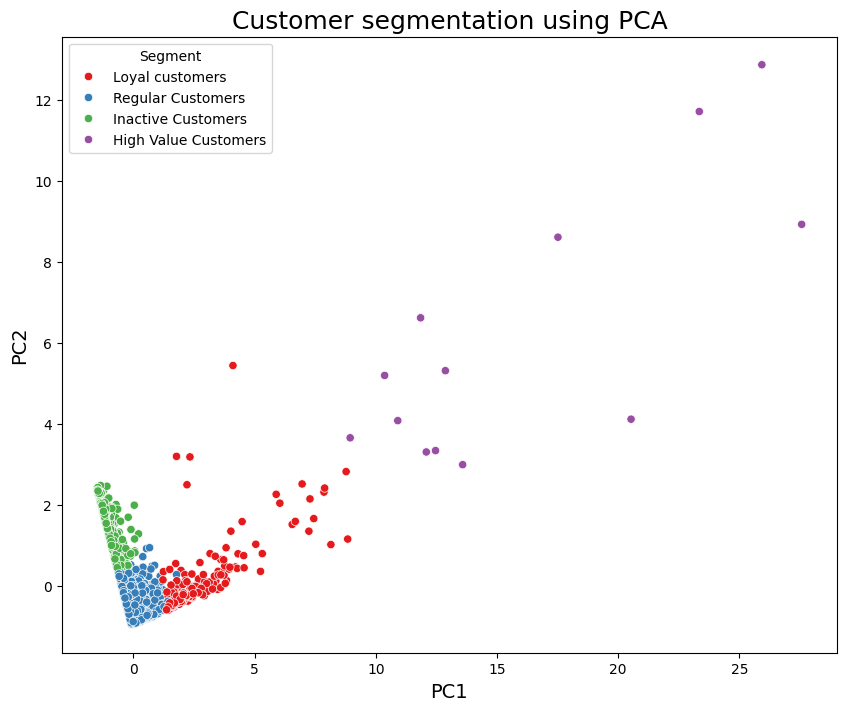

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
rfm_pca_df["Segment"]=rfm_pca_df["Cluster"].map(cluster_mapping)
plt.figure(figsize=(10,8))
sns.scatterplot(data=rfm_pca_df, x="PC1", y="PC2", hue="Segment", palette="Set1")
plt.title("Customer segmentation using PCA", fontsize=18)
plt.xlabel("PC1", fontsize=14)
plt.ylabel("PC2", fontsize=14)
plt.show()

PCA Scatter Plot says,
> Clusters mostly seperated / Slightly OverLapping.

> Shows segmentation effectiveness.

## Count Plot

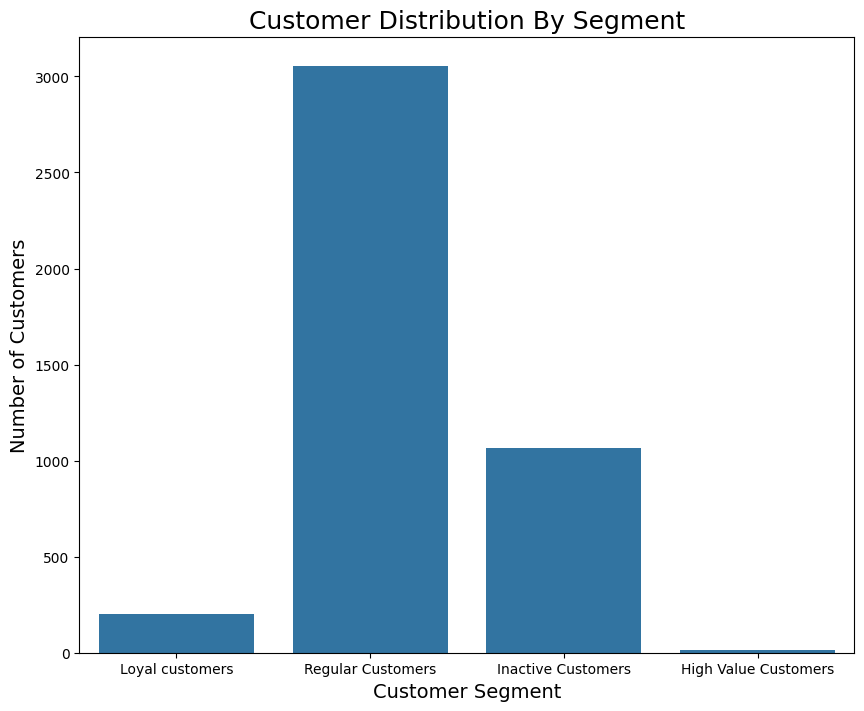

In [52]:
plt.figure(figsize=(10,8))
sns.countplot(x="Segment", data=rfm_pca_df)
plt.xlabel('Customer Segment', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.title("Customer Distribution By Segment", fontsize=18)
plt.show()

## Monetary Box Plot
> Who spends more, clear comparision.

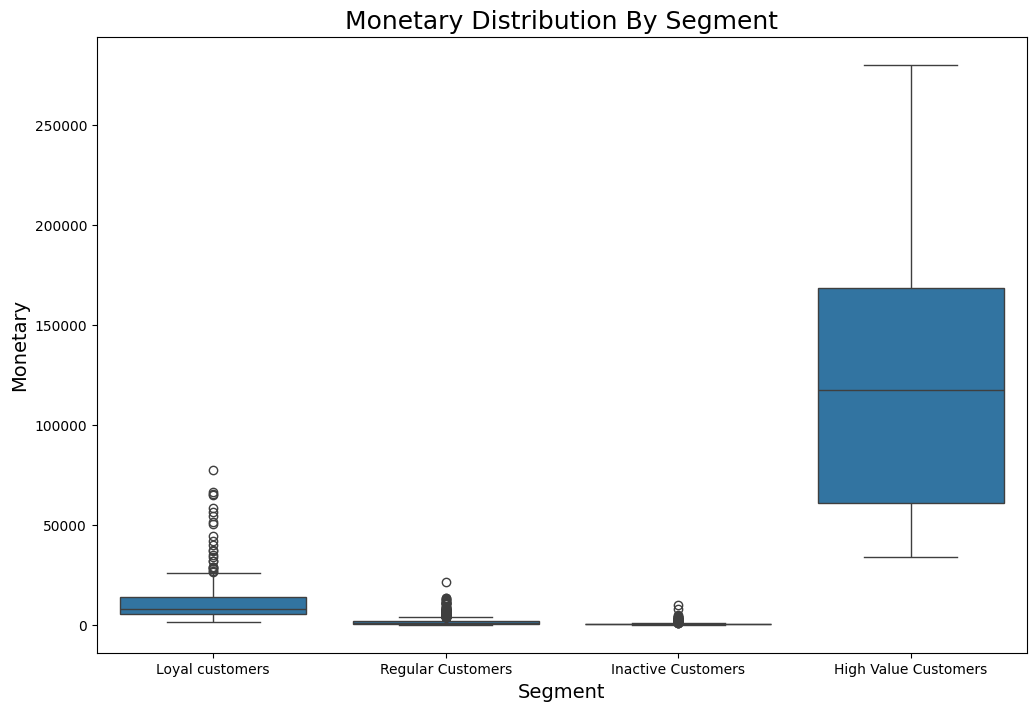

In [53]:
plt.figure(figsize=(12,8))
sns.boxplot(x="Segment", y="Monetary", data=rfm)
plt.title("Monetary Distribution By Segment", fontsize=18)
plt.xlabel("Segment", fontsize=14)
plt.ylabel("Monetary", fontsize=14)
plt.show()

## Frequency Box Plot
> Loyalty Comparision

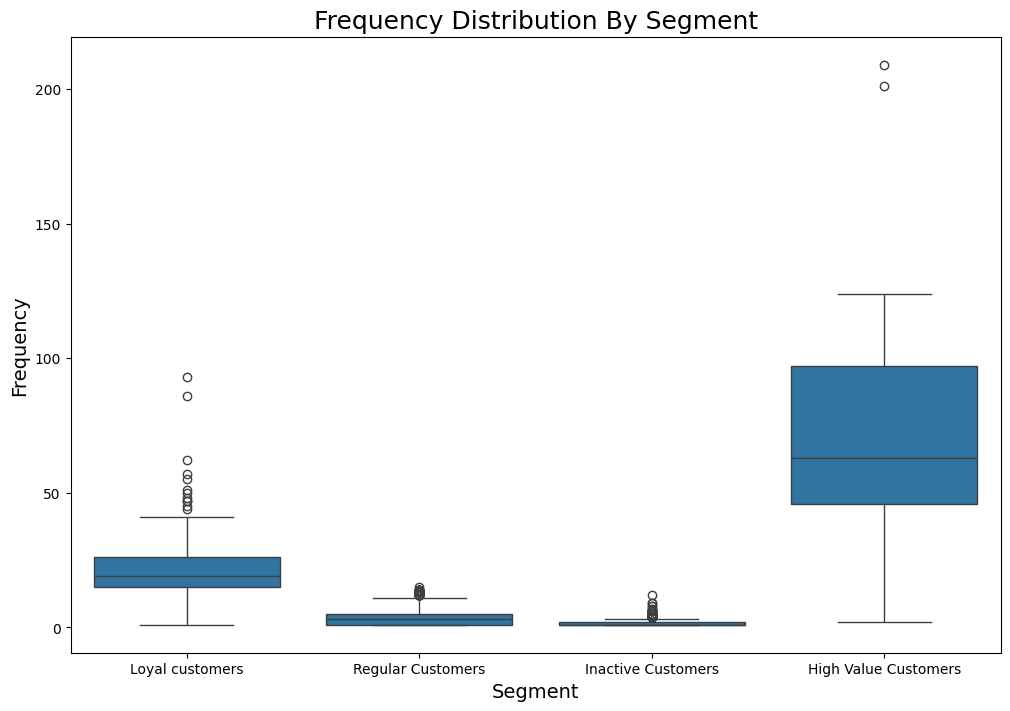

In [55]:
plt.figure(figsize=(12,8))
sns.boxplot(x="Segment", y="Frequency", data=rfm)
plt.title("Frequency Distribution By Segment", fontsize=18)
plt.xlabel("Segment", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.show()

## Recency Box Plot
>Activity Comparision

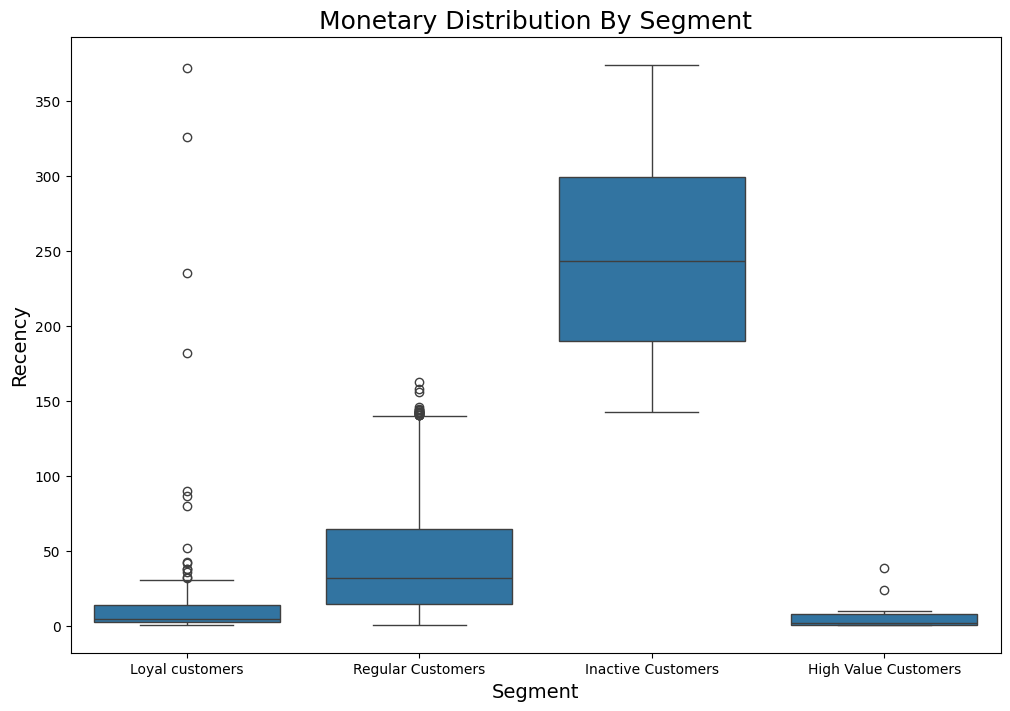

In [56]:
plt.figure(figsize=(12,8))
sns.boxplot(x="Segment", y="Recency", data=rfm)
plt.title("Monetary Distribution By Segment", fontsize=18)
plt.xlabel("Segment", fontsize=14)
plt.ylabel("Recency", fontsize=14)
plt.show()

### Outlier Analysis

Boxplots reveal the presence of outliers in the dataset, particularly in the Monetary and Frequency features.
These outliers represent customers with exceptionally high spending or purchase frequency, indicating high-value or loyal customers.

# Key Insights

- High Value customers contribute significantly to revenue with frequent and recent purchases.
- Loyal customers show consistent engagement but lower spending compared to high-value customers.
- Regular customers have moderate purchasing behavior.
- Inactive customers have low engagement and minimal contribution.

# Business Recommendations

- Retain high-value customers with personalized offers and exclusive benefits.
- Encourage regular customers to become loyal through loyalty programs.
- Re-engage inactive customers using targeted campaigns and discounts.

# Conclusion

> RFM analysis combined with K-Means clustering successfully segments customers based on their behavior.
These insights can help businesses improve customer retention and marketing strategies.